In [1]:
# first quick look at the data from jill's test platform run

In [94]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Sans'
# plt.rcParams['figure.figsize'] = (3,2)
# plt.rcParams["figure.dpi"] = 300
import os

In [119]:
overDF = pd.read_csv('./output/stationTest.CSV')

noMagDF = pd.read_csv('./output/noMagTRES5.CSV')

In [120]:
noMagDF

,timecode,seconds,lat,lat_dir,lon,lon_dir,sensor
0,260409_212230_000,76950.000,4200.0161,N,8739.3662,W,894
1,260409_212230_432,76950.430,4200.0161,N,8739.3662,W,895
2,260409_212230_531,76950.531,4200.0161,N,8739.3662,W,904
3,260409_212230_631,76950.633,4200.0161,N,8739.3662,W,904
4,260409_212230_731,76950.734,4200.0161,N,8739.3662,W,891
...,...,...,...,...,...,...,...
4916,260409_213042_100,77442.102,4159.9673,N,8739.4170,W,902
4917,260409_213042_200,77442.203,4159.9673,N,8739.4170,W,903
4918,260409_213042_300,77442.297,4159.9673,N,8739.4170,W,899
4919,260409_213042_400,77442.398,4159.9673,N,8739.4170,W,903


In [121]:
overDF['sensor'] = pd.to_numeric(overDF['sensor'], errors='coerce')
overDF['sensor']

overDF['seconds'] = pd.to_numeric(overDF['seconds'], errors='coerce')

In [122]:
noMagSens = np.array(noMagDF['sensor'])

noMagSecs = np.array(noMagDF['seconds'])

In [123]:
# noMagSens = noMagSens[1000:-1000]
# noMagSecs = noMagSecs[1000:-1000]

noMagVolt = noMagSens * 5 / 16383

In [124]:
overSens = np.array(overDF['sensor'])

overSecs = np.array(overDF['seconds'])

In [125]:
overSens = overSens[1000:-1000]
overSecs = overSecs[1000:-1000]

In [126]:
overVolt = overSens * 5 / 16383

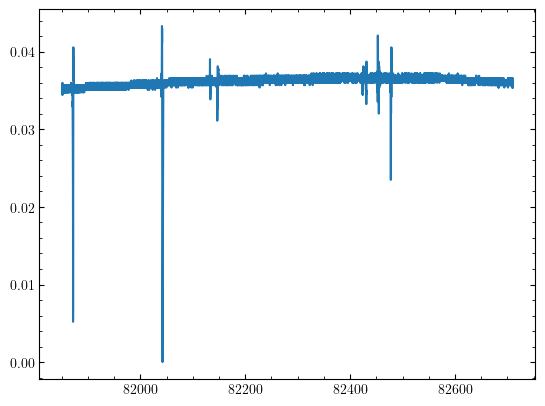

In [127]:
plt.plot(overSecs,overVolt)

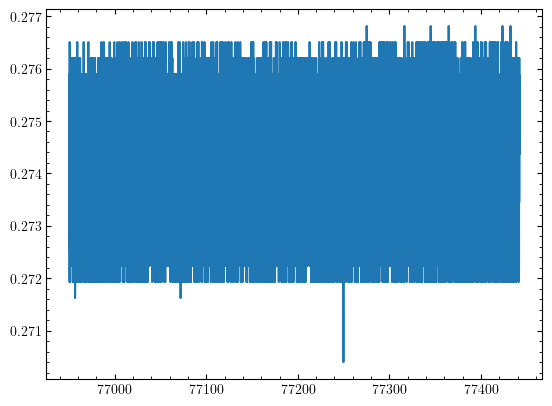

In [129]:
plt.plot(noMagSecs,noMagVolt)
# plt.xlim(71000,72000)

In [130]:
# maybe this low frequency osc is an issue with the grounding of inputs into the amp, will check all wiring today

In [131]:
noMagF,noMagPSD = sp.signal.welch(noMagVolt,fs=100,nperseg=300)

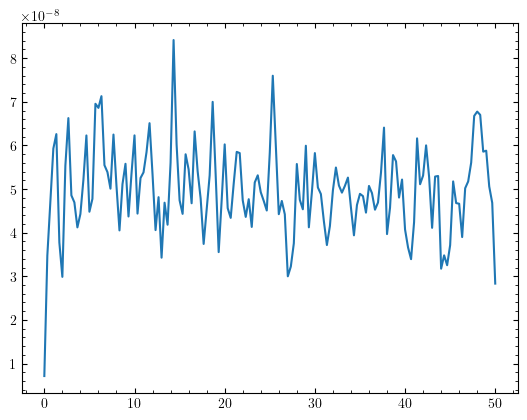

In [140]:
plt.plot(noMagF,noMagPSD)
# plt.xlim(10,50)
# plt.semilogy()

In [133]:
overF,overPSD = sp.signal.welch(overVolt,fs=100,nperseg=300)

(10.0, 50.0)

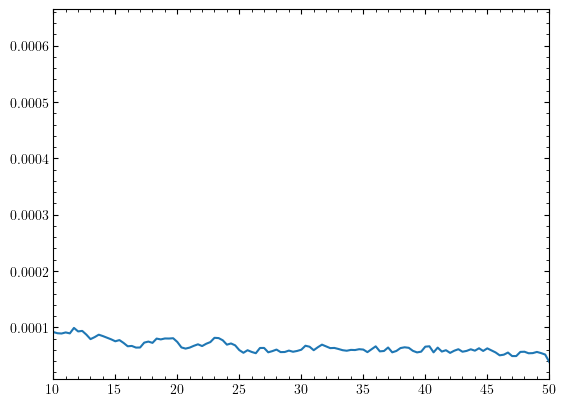

In [134]:
plt.plot(overF,np.sqrt(overPSD))
plt.xlim(10,50)
# plt.ylim(1e-10,1e-8)
# plt.semilogy()

Text(0, 0.5, '$V/\\sqrt{Hz}$')

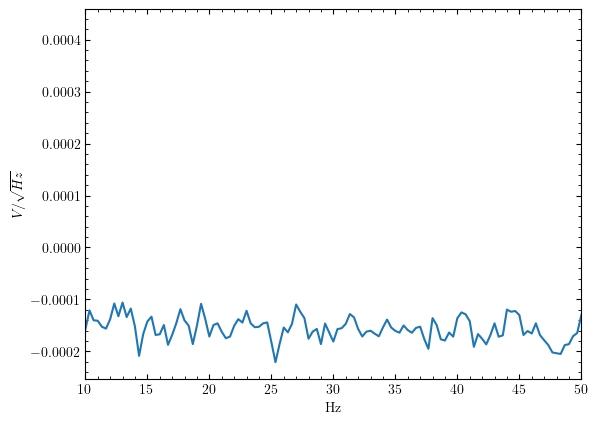

In [137]:
plt.plot(overF,(np.sqrt(overPSD)-np.sqrt(noMagPSD)))
plt.xlim(10,50)
# plt.ylim(0.00002,0.0001)
plt.xlabel('Hz')
plt.ylabel(r'$V/\sqrt{Hz}$')
# plt.semilogy()